# 08 LGBM Hyperparameter Tuning

This notebook follows the same data setup as `07_lgbm_temperature_prediction.ipynb` and only tunes LightGBM parameters. Train dates are used for fitting, valid dates are used for hyperparameter selection, and test dates are kept for the final check only.

## Parameter Search Space

| Parameter | Range | Meaning |
|---|---:|---|
| `num_leaves` | 16 to 128 | Maximum leaf count per tree. Larger values learn more complex patterns but can overfit. |
| `max_depth` | 3 to 12 | Maximum tree depth. Lower values force simpler trees. |
| `learning_rate` | 0.005 to 0.08 | Step size for each tree. Smaller values are usually more stable but need more trees. |
| `min_child_samples` | 10 to 200 | Minimum rows in one leaf. Larger values make the model more conservative. |
| `reg_lambda` | 1e-8 to 20 | L2 regularization. Smooths model behavior. |

`subsample`, `colsample_bytree`, `reg_alpha`, and `min_split_gain` are fixed to keep tuning faster. `n_estimators` is set high and controlled by early stopping.

## Setup

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import optuna
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Missing optuna. Install with: conda install -c conda-forge optuna') from exc

try:
    import lightgbm as lgb
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Missing lightgbm. Install it in the active environment before tuning.') from exc

import config
from lgbm_temperature import (
    CATEGORICAL_FEATURES,
    build_lgbm_dataset,
    regression_metrics,
    split_by_dates,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
config.ensure_output_dirs()

/opt/miniconda3/envs/itp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Same Settings as 07

In [2]:
TEMPERATURE_COLUMN = 'temp_mean_c'
TARGET_MINUTES_LIST = [5.0, 10.0]
PEOPLE_OR_MACHINE = 'machine'

TRAIN_DATES = ['2025-04-23', '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-06', '2025-05-07']
VALID_DATES = ['2025-04-25']
TEST_DATES = ['2025-04-24', '2025-05-02']

RANDOM_STATE = 42
N_TRIALS = 50
TIMEOUT_PER_HORIZON = None
N_ESTIMATORS = 2000
EARLY_STOPPING_ROUNDS = 80

TUNING_DIR = config.LGBM_OUTPUT_DIR / 'tuning'
TUNING_DIR.mkdir(parents=True, exist_ok=True)

## Build Datasets

In [3]:
def horizon_tag(target_minutes):
    return f'{int(target_minutes):02d}min'


def build_split_for_horizon(target_minutes):
    model_df, feature_columns = build_lgbm_dataset(
        timeline_csv=config.OBJECT_TIMELINE_CSV,
        temperature_column=TEMPERATURE_COLUMN,
        target_horizon=1,
        target_minutes=target_minutes,
        people_or_machine=PEOPLE_OR_MACHINE,
    )
    train_df, valid_df, test_df = split_by_dates(model_df, TRAIN_DATES, VALID_DATES, TEST_DATES)
    return {
        'target_minutes': target_minutes,
        'model_df': model_df,
        'feature_columns': feature_columns,
        'train_df': train_df,
        'valid_df': valid_df,
        'test_df': test_df,
    }


datasets = {target_minutes: build_split_for_horizon(target_minutes) for target_minutes in TARGET_MINUTES_LIST}

dataset_summary = []
for target_minutes, data in datasets.items():
    dataset_summary.append({
        'horizon': horizon_tag(target_minutes),
        'model_rows': len(data['model_df']),
        'train_rows': len(data['train_df']),
        'valid_rows': len(data['valid_df']),
        'test_rows': len(data['test_df']),
        'features': len(data['feature_columns']),
    })

pd.DataFrame(dataset_summary)

,horizon,model_rows,train_rows,valid_rows,test_rows,features
0,05min,55249,32475,7424,15350,60
1,10min,55027,32375,7377,15275,60


## Training Helpers

In [4]:
BASELINE_PARAMS = {
    'n_estimators': 1200,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
}

FIXED_TUNING_PARAMS = {
    'subsample': 0.85,
    'subsample_freq': 1,
    'colsample_bytree': 0.85,
    'reg_alpha': 0.0,
    'min_split_gain': 0.0,
}


def suggest_lgbm_params(trial):
    return {
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 20.0, log=True),
    }


def make_model(params, random_state=RANDOM_STATE):
    params = {**FIXED_TUNING_PARAMS, **dict(params)}
    n_estimators = params.pop('n_estimators', N_ESTIMATORS)
    return lgb.LGBMRegressor(
        objective='regression',
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
        **params,
    )


def fit_lgbm(train_df, valid_df, feature_columns, params):
    evals_result = {}
    model = make_model(params)
    model.fit(
        train_df[feature_columns],
        train_df['target_temp'],
        eval_set=[
            (train_df[feature_columns], train_df['target_temp']),
            (valid_df[feature_columns], valid_df['target_temp']),
        ],
        eval_names=['train', 'valid'],
        eval_metric='rmse',
        callbacks=[
            lgb.record_evaluation(evals_result),
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
        ],
        categorical_feature=CATEGORICAL_FEATURES,
    )
    return model, evals_result


def evaluate_model(model, data, feature_columns):
    rows = []
    for split_name in ['train', 'valid', 'test']:
        split_df = data[f'{split_name}_df']
        prediction = model.predict(split_df[feature_columns])
        rows.append({'split': split_name, **regression_metrics(split_df['target_temp'], prediction)})
    return pd.DataFrame(rows)

## Baseline from Current 07

In [5]:
baseline_rows = []
baseline_results = {}

for target_minutes, data in datasets.items():
    model, evals_result = fit_lgbm(data['train_df'], data['valid_df'], data['feature_columns'], BASELINE_PARAMS)
    metrics = evaluate_model(model, data, data['feature_columns'])
    metrics.insert(0, 'horizon', horizon_tag(target_minutes))
    baseline_rows.append(metrics)
    baseline_results[target_minutes] = {'model': model, 'evals_result': evals_result, 'metrics': metrics}

baseline_metrics = pd.concat(baseline_rows, ignore_index=True)
baseline_metrics

,horizon,split,mae,rmse,r2
0,05min,train,0.303330,0.449832,0.842259
1,05min,valid,0.441188,0.575592,0.452897
2,05min,test,0.313311,0.425572,0.746722
3,10min,train,0.309304,0.450744,0.842316
4,10min,valid,0.511778,0.642543,0.349639
5,10min,test,0.372075,0.488830,0.665397


## Optuna TPE Tuning

In [6]:
def tune_one_horizon(target_minutes, data):
    tag = horizon_tag(target_minutes)
    output_dir = TUNING_DIR / tag
    output_dir.mkdir(parents=True, exist_ok=True)

    def objective(trial):
        params = suggest_lgbm_params(trial)
        model, _ = fit_lgbm(data['train_df'], data['valid_df'], data['feature_columns'], params)
        valid_prediction = model.predict(data['valid_df'][data['feature_columns']])
        valid_metrics = regression_metrics(data['valid_df']['target_temp'], valid_prediction)
        trial.set_user_attr('best_iteration', getattr(model, 'best_iteration_', None))
        trial.set_user_attr('valid_mae', valid_metrics['mae'])
        trial.set_user_attr('valid_r2', valid_metrics['r2'])
        return valid_metrics['rmse']

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=f'lgbm_{tag}_tuning',
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_PER_HORIZON, show_progress_bar=False)

    trials_df = study.trials_dataframe()
    trials_df.to_csv(output_dir / 'optuna_trials.csv', index=False)

    best_params = {**FIXED_TUNING_PARAMS, **dict(study.best_params)}
    best_params['n_estimators'] = N_ESTIMATORS
    with (output_dir / 'best_params.json').open('w', encoding='utf-8') as handle:
        json.dump(best_params, handle, indent=2)

    best_model, best_evals = fit_lgbm(data['train_df'], data['valid_df'], data['feature_columns'], best_params)
    best_metrics = evaluate_model(best_model, data, data['feature_columns'])
    best_metrics.insert(0, 'horizon', tag)
    best_metrics.to_csv(output_dir / 'best_metrics.csv', index=False)

    return {
        'study': study,
        'trials_df': trials_df,
        'best_params': best_params,
        'best_model': best_model,
        'best_evals': best_evals,
        'best_metrics': best_metrics,
        'output_dir': output_dir,
    }


tuning_results = {}
for target_minutes, data in datasets.items():
    print(f'Tuning {horizon_tag(target_minutes)} with {N_TRIALS} trials')
    tuning_results[target_minutes] = tune_one_horizon(target_minutes, data)

best_params_by_horizon = {horizon_tag(k): v['best_params'] for k, v in tuning_results.items()}
with (TUNING_DIR / 'best_lgbm_params.json').open('w', encoding='utf-8') as handle:
    json.dump(best_params_by_horizon, handle, indent=2)

best_params_by_horizon

Tuning 05min with 50 trials
Tuning 10min with 50 trials


{'05min': {'subsample': 0.85,
  'subsample_freq': 1,
  'colsample_bytree': 0.85,
  'reg_alpha': 0.0,
  'min_split_gain': 0.0,
  'num_leaves': 79,
  'max_depth': 10,
  'learning_rate': 0.04767900838150994,
  'min_child_samples': 199,
  'reg_lambda': 0.00020116039695574183,
  'n_estimators': 2000},
 '10min': {'subsample': 0.85,
  'subsample_freq': 1,
  'colsample_bytree': 0.85,
  'reg_alpha': 0.0,
  'min_split_gain': 0.0,
  'num_leaves': 16,
  'max_depth': 6,
  'learning_rate': 0.04178930249466568,
  'min_child_samples': 168,
  'reg_lambda': 0.0004606636021494949,
  'n_estimators': 2000}}

## 07 Integration Output

This is the parameter file that notebook 07 can read when USE_TUNED_PARAMS is set to True. Keep test results separate from tuning decisions: use validation to choose parameters, then rerun 07 to produce the final tuned predictions.


In [7]:
expected_tags = [horizon_tag(target_minutes) for target_minutes in TARGET_MINUTES_LIST]
missing_tags = [tag for tag in expected_tags if tag not in best_params_by_horizon]
if missing_tags:
    raise KeyError(f'Missing tuned parameter sets for: {missing_tags}')

params_for_07_path = TUNING_DIR / 'best_lgbm_params.json'
params_for_07_preview = pd.DataFrame.from_dict(best_params_by_horizon, orient='index')
params_for_07_preview.index.name = 'horizon'
params_for_07_preview.to_csv(TUNING_DIR / 'best_lgbm_params_for_07_preview.csv')

print('07 can use tuned params from:')
print(params_for_07_path)
print('In 07_lgbm_temperature_prediction.ipynb, set: USE_TUNED_PARAMS = True')
display(params_for_07_preview)


07 can use tuned params from:
/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/lgbm/tuning/best_lgbm_params.json
In 07_lgbm_temperature_prediction.ipynb, set: USE_TUNED_PARAMS = True


,subsample,subsample_freq,colsample_bytree,reg_alpha,min_split_gain,num_leaves,max_depth,learning_rate,min_child_samples,reg_lambda,n_estimators
horizon,,,,,,,,,,,
05min,0.85,1,0.85,0.0,0.0,79,10,0.047679,199,0.000201,2000
10min,0.85,1,0.85,0.0,0.0,16,6,0.041789,168,0.000461,2000


## Baseline vs Tuned Metrics

In [8]:
tuned_metrics = pd.concat([result['best_metrics'] for result in tuning_results.values()], ignore_index=True)
baseline_compare = baseline_metrics.copy()
baseline_compare.insert(1, 'model', 'baseline_07')
tuned_compare = tuned_metrics.copy()
tuned_compare.insert(1, 'model', 'tuned')

comparison_metrics = pd.concat([baseline_compare, tuned_compare], ignore_index=True)
comparison_metrics.to_csv(TUNING_DIR / 'baseline_vs_tuned_metrics.csv', index=False)
comparison_metrics

,horizon,model,split,mae,rmse,r2
0,05min,baseline_07,train,0.303330,0.449832,0.842259
1,05min,baseline_07,valid,0.441188,0.575592,0.452897
2,05min,baseline_07,test,0.313311,0.425572,0.746722
3,10min,baseline_07,train,0.309304,0.450744,0.842316
4,10min,baseline_07,valid,0.511778,0.642543,0.349639
5,10min,baseline_07,test,0.372075,0.488830,0.665397
6,05min,tuned,train,0.277044,0.425386,0.858937
7,05min,tuned,valid,0.417946,0.558779,0.484393
8,05min,tuned,test,0.306516,0.424391,0.748126
9,10min,tuned,train,0.329831,0.491693,0.812364


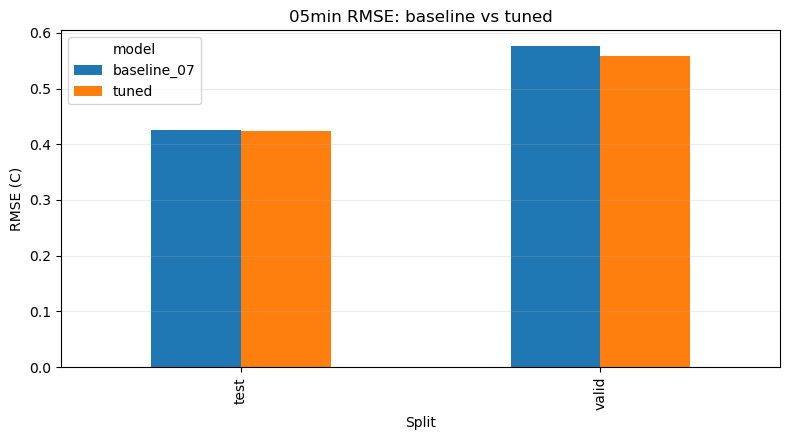

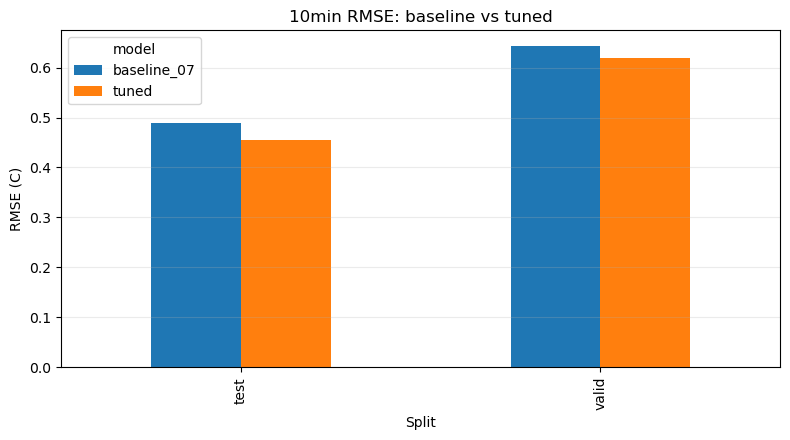

In [9]:
plot_df = comparison_metrics[comparison_metrics['split'].isin(['valid', 'test'])].copy()
for horizon, horizon_df in plot_df.groupby('horizon'):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    pivot = horizon_df.pivot_table(index='split', columns='model', values='rmse')
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'{horizon} RMSE: baseline vs tuned')
    ax.set_xlabel('Split')
    ax.set_ylabel('RMSE (C)')
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    output_path = TUNING_DIR / horizon / 'baseline_vs_tuned_rmse.png'
    fig.savefig(output_path, dpi=160)
    display(fig)
    plt.close(fig)

## Optimization History

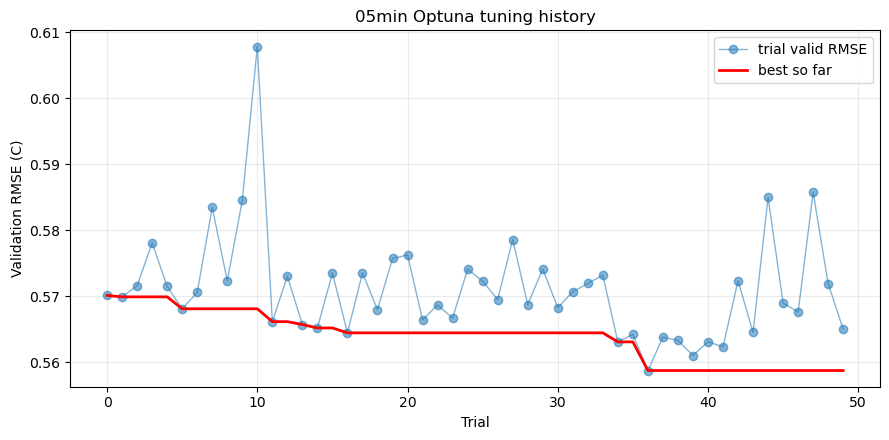

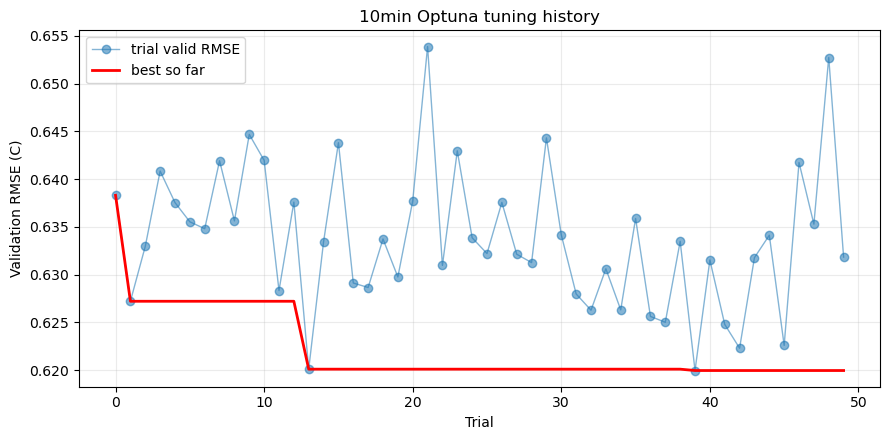

In [10]:
for target_minutes, result in tuning_results.items():
    tag = horizon_tag(target_minutes)
    trials_df = result['trials_df'].copy()
    completed = trials_df[trials_df['state'] == 'COMPLETE'].copy()
    completed['best_rmse_so_far'] = completed['value'].cummin()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(completed['number'], completed['value'], marker='o', linewidth=1.0, alpha=0.55, label='trial valid RMSE')
    ax.plot(completed['number'], completed['best_rmse_so_far'], color='red', linewidth=2.0, label='best so far')
    ax.set_title(f'{tag} Optuna tuning history')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Validation RMSE (C)')
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    output_path = result['output_dir'] / 'optimization_history.png'
    fig.savefig(output_path, dpi=160)
    display(fig)
    plt.close(fig)

## Parameter Importance

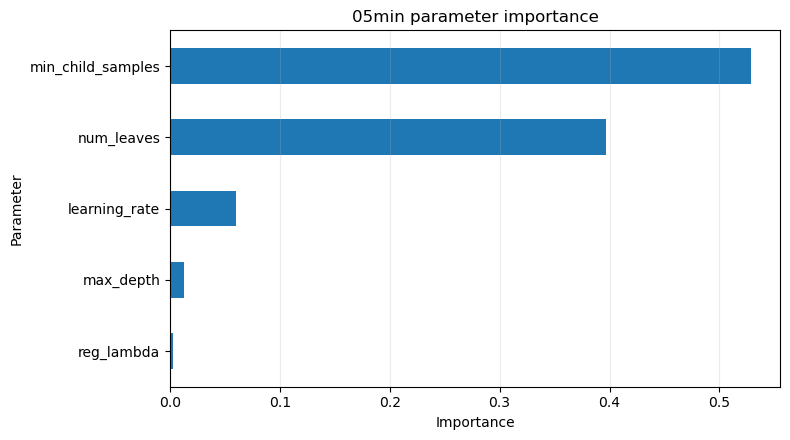

,parameter,importance
0,min_child_samples,0.528694
1,num_leaves,0.396847
2,learning_rate,0.059638
3,max_depth,0.012553
4,reg_lambda,0.002268


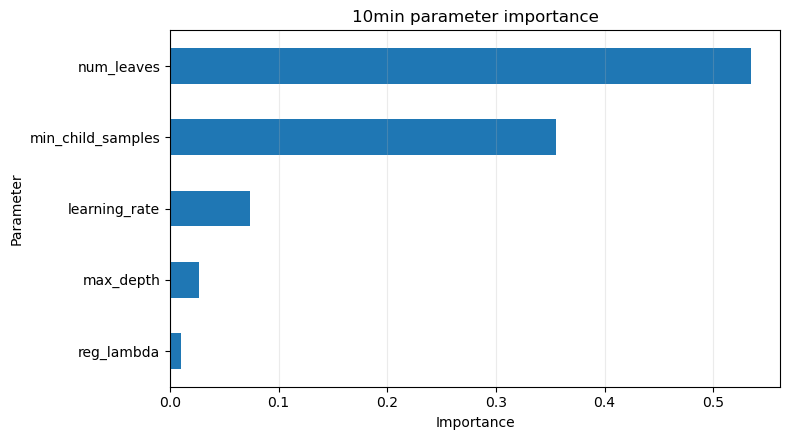

,parameter,importance
0,num_leaves,0.534725
1,min_child_samples,0.355114
2,learning_rate,0.073575
3,max_depth,0.026569
4,reg_lambda,0.010017


In [11]:
for target_minutes, result in tuning_results.items():
    tag = horizon_tag(target_minutes)
    try:
        importance = optuna.importance.get_param_importances(result['study'])
    except Exception as exc:
        print(f'{tag}: parameter importance unavailable: {exc}')
        continue

    importance_df = pd.DataFrame({'parameter': list(importance.keys()), 'importance': list(importance.values())})
    importance_df.to_csv(result['output_dir'] / 'param_importance.csv', index=False)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    importance_df.sort_values('importance').plot.barh(x='parameter', y='importance', ax=ax, legend=False, color='#1f77b4')
    ax.set_title(f'{tag} parameter importance')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Parameter')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()
    output_path = result['output_dir'] / 'param_importance.png'
    fig.savefig(output_path, dpi=160)
    display(fig)
    plt.close(fig)
    display(importance_df)

## Output Files

In [12]:
output_files = []
for target_minutes, result in tuning_results.items():
    tag = horizon_tag(target_minutes)
    for path in sorted(result['output_dir'].glob('*')):
        output_files.append({'horizon': tag, 'path': str(path)})
output_files.append({'horizon': 'all', 'path': str(TUNING_DIR / 'best_lgbm_params.json')})
output_files.append({'horizon': 'all', 'path': str(TUNING_DIR / 'best_lgbm_params_for_07_preview.csv')})
output_files.append({'horizon': 'all', 'path': str(TUNING_DIR / 'baseline_vs_tuned_metrics.csv')})
pd.DataFrame(output_files)

,horizon,path
0,05min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
1,05min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
2,05min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
3,05min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
4,05min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
5,05min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
6,05min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
7,10min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
8,10min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
9,10min,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...
